# Sprint Distance — Daily Load Prediction

End-to-end pipeline for predicting a player's **sprint distance (metres (sprint))** on a given training day.

| | |
|---|---|
| **Target** | `sprint_distance` — daily sum across all training periods |
| **Transform** | `log1p`; back-transformed with `expm1` at evaluation |
| **Split** | Chronological 80/20 on unique dates (no row shuffling) |
| **CV** | Date-blocked expanding-window (4 folds, panel-safe) |
| **Models** | LightGBM · XGBoost · Random Forest — full feature + top-5 SHAP retraining |

> **Note:** `total_distance` is aggregated alongside `sprint_distance` for context in `_add_features`, but is **dropped before training** to prevent same-session leakage.

---
## Imports & Paths

All third-party packages are imported up front. Paths are resolved relative to the notebook's working directory.

In [1]:
import math
import warnings
import zipfile
from pathlib import Path

import joblib
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from lightgbm import LGBMRegressor
from scipy import stats as scipy_stats
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from tqdm.notebook import tqdm
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

# Paths
REPO_ROOT   = Path.cwd()
DATA_DIR    = REPO_ROOT / "data"
RAW_CSV     = DATA_DIR / "raw" / "data_acute_vs_chronic.csv"
RAW_ZIP     = DATA_DIR / "data_acute_vs_chronic.zip"
MODELS_DIR  = REPO_ROOT / "models"
REPORTS_DIR = REPO_ROOT / "reports"
TARGET      = "sprint_distance"
FIGURES_DIR = REPORTS_DIR / "figures" / TARGET
MODEL_DIR   = MODELS_DIR / "notebook_experiments" / TARGET
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

---
# Part A — Data Pipeline

Ingest raw period-level GPS/IMU records, clean and validate them, aggregate to player-day level, engineer temporal features, and prepare train/test sets.

## 0. Data Loading

Raw dataset: one row per **training period** (a single exercise block within a session day). A player can accumulate multiple periods in one day — e.g. a tactical block (`TAC`), a gym block (`G`), and a match (`MATCH`). Aggregation to player-day happens in Section 3.

If the CSV is absent, the bootstrap archive is extracted automatically.

In [2]:
if not RAW_CSV.exists():
    if not RAW_ZIP.exists():
        raise FileNotFoundError(
            f"Missing raw data. Expected {RAW_CSV} or bootstrap archive {RAW_ZIP}."
        )
    RAW_CSV.parent.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(RAW_ZIP) as archive:
        archive.extract(RAW_CSV.name, path=RAW_CSV.parent)

df = pd.read_csv(RAW_CSV)
print(f"Raw shape: {df.shape}  ({df['player_id'].nunique()} players)")
df.head()

Raw shape: (3903, 13)  (35 players)


,player_id,period_id,period_name,activity_id,period_start_time,position_name_en,is_official_match,total_distance,acc_band7plus_total_effort_count,velocity_band6plus7_total_distance,height,weight,date_of_birth
0,37191,period_1683,BP 2351,activity_1389,2024-12-16T00:00:00Z,Central Back,NaN,1003.372036,0,0.000000,184.0,79.0,1997-06-22
1,37191,period_4407,G 1669,activity_2423,2025-01-01T00:00:00Z,Central Back,NaN,1223.749101,4,4.960388,184.0,79.0,1997-06-22
2,37191,period_883,BP 4893,activity_4655,2025-04-06T00:00:00Z,Central Back,NaN,747.250469,4,0.000000,184.0,79.0,1997-06-22
3,37191,period_1790,G 3164,activity_911,2025-04-03T00:00:00Z,Central Back,NaN,1196.351675,2,0.000000,184.0,79.0,1997-06-22
4,37191,period_2421,BP 0518,activity_3073,2025-05-06T00:00:00Z,Central Back,NaN,322.200458,2,0.000000,184.0,79.0,1997-06-22


## 1. Data Cleaning

Five sequential cleaning steps:

1. **Rename** verbose GPS column names to short aliases.
2. **Fix types** — `is_official_match` nulls indicate training sessions (fill `0`); `player_id` coerced to categorical.
3. **Parse `exercise_type`** from the prefix of `period_name`. Match periods have no `period_name` (fill `"MATCH"` first).
4. **Parse datetimes** — strip timezone info, normalise to midnight.
5. **Compute age** at session date from `date_of_birth`.
6. **Drop rows** from players missing any static metadata (height / weight / position / DOB).

In [3]:
# 1.0 Rename raw columns
df = df.rename(columns={
    'velocity_band6plus7_total_distance': 'sprint_distance',
    'acc_band7plus_total_effort_count':   'accelerations',
})

# 1.1 Fix types
df['is_official_match'] = df['is_official_match'].fillna(0)
df['player_id'] = df['player_id'].astype('category')

# 1.2 Parse exercise_type from period_name
df['period_name']   = df['period_name'].fillna('MATCH')
df['exercise_type'] = df['period_name'].str.split(' ').str[0]
df = df.drop(columns=['is_official_match'])

# 1.3 Parse datetime columns (strip tz, normalise to midnight)
df['period_start_time'] = pd.to_datetime(df['period_start_time']).dt.tz_localize(None).dt.normalize()
df['date_of_birth']     = pd.to_datetime(df['date_of_birth']).dt.tz_localize(None).dt.normalize()

# 1.4 Compute player age at session date
df['age'] = ((df['period_start_time'] - df['date_of_birth']).dt.days / 365.25).round(0)
print(f"Age range: {df['age'].min():.0f}–{df['age'].max():.0f}  |  null ages: {df['age'].isna().sum()}")

# 1.5 Drop rows with missing static metadata
affected = df[df['height'].isna()]
print(f"Dropping {len(affected)} rows from {affected['player_id'].nunique()} player(s) with missing metadata")
df = df.dropna(subset=['height', 'weight', 'position_name_en', 'date_of_birth']).reset_index(drop=True)
assert df[['player_id', 'height', 'weight', 'position_name_en', 'date_of_birth']].isna().sum().sum() == 0
print(f"Clean period-level shape: {df.shape}")

Age range: 17–56  |  null ages: 19
Dropping 19 rows from 1 player(s) with missing metadata
Clean period-level shape: (3884, 14)


## 2. Outlier Treatment

Two distinct anomalies:

| Anomaly | Players | Action |
|---|---|---|
| `total_distance ≥ 20,000 m` for player 94884 | 1 | Replace with median of that player's valid MATCH rows (GPS malfunction) |
| `weight == 200 kg` (placeholder) | 6 | Drop all rows — these are trialists or data-entry errors |

A valid MATCH covers 8,000–11,000 m. The 32,000 m value is physically impossible and would bias the target distribution significantly.

In [4]:
# 2.1 Player 94884 — replace anomalous MATCH distance with within-player median
df_94884_filtered = df[
    (df['player_id'] == 94884) &
    (df['exercise_type'] == 'MATCH') &
    (df['total_distance'] <= 20000)
]
median_distance = df_94884_filtered['total_distance'].median()
print(f"Replacement median for player 94884: {median_distance:.0f} m")

df.loc[
    (df['player_id'] == 94884) & (df['total_distance'] >= 20000),
    'total_distance'
] = median_distance
print(f"Rows still > 20,000 m: {(df['total_distance'] > 20000).sum()}")

Replacement median for player 94884: 1461 m
Rows still > 20,000 m: 0


In [5]:
# 2.2 Trialists — placeholder metadata (weight == 200 kg)
weight_200 = df[df['weight'] == 200].player_id.unique()
for pid in weight_200:
    rows = df[df['player_id'] == pid]
    print(
        f"  Player {pid}: {len(rows)} rows, "
        f"{rows['period_start_time'].min().date()} to {rows['period_start_time'].max().date()}, "
        f"DOB: {rows['date_of_birth'].iloc[0].date()}"
    )

before = len(df)
df = df[~df['player_id'].isin(weight_200)].reset_index(drop=True)
print(f"\nDropped {before - len(df)} rows across {len(weight_200)} players")

assert ((df['height'] == 180) & (df['weight'] == 200)).sum() == 0
assert df['weight'].max() <= 100
print(f"Final period-level dataset: {df.shape}")

  Player 42978: 21 rows, 2024-07-27 to 2024-08-07, DOB: 1969-01-16
  Player 93116: 16 rows, 2024-07-29 to 2024-08-04, DOB: 2007-09-02
  Player 86086: 10 rows, 2024-07-27 to 2024-08-01, DOB: 1969-12-05
  Player 15795: 30 rows, 2024-07-30 to 2025-06-26, DOB: 2005-06-02
  Player 60819: 2 rows, 2025-06-18 to 2025-06-22, DOB: 2003-02-06
  Player 89091: 3 rows, 2025-06-18 to 2025-06-26, DOB: 2004-01-10

Dropped 82 rows across 6 players
Final period-level dataset: (3802, 14)


## 3. Daily Aggregation

Collapse period-level rows to **player-day** level:

- **`sprint_distance`** — sum across all periods (target variable).
- **`total_distance`** — sum across all periods (context covariate; dropped before training).
- **`n_periods`** — count of distinct exercise periods that day.
- **`n_exercise_types`** — count of distinct exercise types.
- **`has_*` flags** — one-hot indicators for each exercise type, summed (≥ 1 means that type occurred).
- **Static attributes** — `height`, `weight`, `age`, `position` carried through via `.first()`.

In [6]:
# One-hot encode exercise_type per period, then sum to day level
et_dummies = pd.get_dummies(df['exercise_type'], prefix='has').astype(int)
df_enc = pd.concat([df[['player_id', 'period_start_time']], et_dummies], axis=1)
et_daily = (
    df_enc.groupby(['player_id', 'period_start_time'], observed=True)
    .sum()
    .reset_index()
)

daily = (
    df.groupby(['player_id', 'period_start_time'], observed=True)
    .agg(
        **{
            TARGET:              (TARGET,            'sum'),
            'total_distance':    ('total_distance',  'sum'),   # context covariate — dropped before training
            'n_periods':         ('activity_id',     'count'),
            'n_exercise_types':  ('exercise_type',   'nunique'),
            'height':            ('height',          'first'),
            'weight':            ('weight',          'first'),
            'age':               ('age',             'first'),
            'position':          ('position_name_en','first'),
        }
    )
    .reset_index()
    .merge(et_daily, on=['player_id', 'period_start_time'])
    .rename(columns={'period_start_time': 'date'})
    .sort_values(['player_id', 'date'])
    .reset_index(drop=True)
)

print(f"Daily shape: {daily.shape}")
daily.head(10)

Daily shape: (2103, 15)


,player_id,date,sprint_distance,total_distance,n_periods,n_exercise_types,height,weight,age,position,has_BP,has_G,has_MATCH,has_TAC,has_TEC
0,11983,2024-07-29,81.922951,3751.549912,3,3,172.0,66.0,39.0,Central Midfielder,1,1,0,1,0
1,11983,2024-07-30,0.000000,6059.586836,3,3,172.0,66.0,39.0,Central Midfielder,1,1,0,1,0
2,11983,2024-08-01,59.335029,5182.181222,5,4,172.0,66.0,39.0,Central Midfielder,1,1,2,0,1
3,11983,2024-08-02,37.537185,2842.762421,3,3,172.0,66.0,39.0,Central Midfielder,1,1,0,1,0
4,11983,2024-08-03,20.534596,1479.106082,1,1,172.0,66.0,39.0,Central Midfielder,0,0,1,0,0
5,11983,2024-08-04,84.679132,3269.121551,2,1,172.0,66.0,39.0,Central Midfielder,0,0,2,0,0
6,11983,2024-08-06,25.511082,1074.314020,1,1,172.0,66.0,39.0,Central Midfielder,0,0,1,0,0
7,11983,2024-08-07,13.604527,1246.603416,1,1,172.0,66.0,39.0,Central Midfielder,0,0,1,0,0
8,11983,2024-08-10,0.000000,4198.305953,2,2,172.0,66.0,39.0,Central Midfielder,1,0,0,1,0
9,11983,2024-08-11,10.987846,2778.790187,3,2,172.0,66.0,39.0,Central Midfielder,0,2,0,1,0


## 3.1 Fill Missing Dates — Rest Days

Each player's date range contains gaps (days with no recorded activity). These are genuine **rest days** and must appear in the dataset so that temporal features (lags, rolling MAs, EWMA) compute correctly over a contiguous calendar.

For each player, a full daily spine is created from their first to last recorded date. Missing dates are left-joined in and filled:
- **Load columns** (`sprint_distance`, `total_distance`, `n_periods`, `n_exercise_types`, `has_*`) → `0`.
- **Static attributes** (`height`, `weight`, `age`, `position`) → forward-filled then back-filled within each player.

In [7]:
zero_cols   = ['sprint_distance', 'total_distance', 'n_periods', 'n_exercise_types'] + \
              [c for c in daily.columns if c.startswith('has_')]
static_cols = ['height', 'weight', 'age', 'position']

player_date_range = daily.groupby('player_id', observed=True)['date'].agg(['min', 'max'])
spines = [
    pd.DataFrame({'player_id': pid, 'date': pd.date_range(row['min'], row['max'], freq='D')})
    for pid, row in tqdm(player_date_range.iterrows(), total=len(player_date_range), desc="Building date spine")
]
spine = pd.concat(spines, ignore_index=True)
spine['player_id'] = spine['player_id'].astype(daily['player_id'].dtype)

daily = (
    spine
    .merge(daily, on=['player_id', 'date'], how='left')
    .sort_values(['player_id', 'date'])
    .reset_index(drop=True)
)

daily[zero_cols]   = daily[zero_cols].fillna(0)
daily[static_cols] = (
    daily.groupby('player_id', observed=True)[static_cols]
    .transform(lambda s: s.ffill().bfill())
)

print(f"Daily shape after spine fill: {daily.shape}")
print(f"Null count: {daily.isna().sum().sum()}")
daily.head()

Building date spine:   0%|          | 0/28 [00:00<?, ?it/s]

Daily shape after spine fill: (6310, 15)
Null count: 0


,player_id,date,sprint_distance,total_distance,n_periods,n_exercise_types,height,weight,age,position,has_BP,has_G,has_MATCH,has_TAC,has_TEC
0,11983,2024-07-29,81.922951,3751.549912,3.0,3.0,172.0,66.0,39.0,Central Midfielder,1.0,1.0,0.0,1.0,0.0
1,11983,2024-07-30,0.000000,6059.586836,3.0,3.0,172.0,66.0,39.0,Central Midfielder,1.0,1.0,0.0,1.0,0.0
2,11983,2024-07-31,0.000000,0.000000,0.0,0.0,172.0,66.0,39.0,Central Midfielder,0.0,0.0,0.0,0.0,0.0
3,11983,2024-08-01,59.335029,5182.181222,5.0,4.0,172.0,66.0,39.0,Central Midfielder,1.0,1.0,2.0,0.0,1.0
4,11983,2024-08-02,37.537185,2842.762421,3.0,3.0,172.0,66.0,39.0,Central Midfielder,1.0,1.0,0.0,1.0,0.0


## 4. Train / Test Split — Chronological 80 / 20

The split is made on **unique calendar dates**, not rows. This guarantees:
- All players' data for a given date land in the same partition (no cross-date contamination).
- The 80 % earliest dates form the training set; the 20 % latest dates form the test set.
- No shuffling — temporal order is preserved, which is essential for load-history features.

Feature engineering (Section 5) is applied **separately** to each partition after this split, so no test-date information informs training-set features.

In [8]:
all_dates = np.sort(daily['date'].unique())
cutoff    = all_dates[int(len(all_dates) * 0.8) - 1]

train_base = daily[daily['date'] <= cutoff].copy().reset_index(drop=True)
test_base  = daily[daily['date'] >  cutoff].copy().reset_index(drop=True)

print(f"Train: {train_base['date'].min().date()} → {train_base['date'].max().date()}  "
      f"({train_base['date'].nunique()} dates, {len(train_base)} rows)")
print(f"Test:  {test_base['date'].min().date()} → {test_base['date'].max().date()}  "
      f"({test_base['date'].nunique()} dates, {len(test_base)} rows)")

Train: 2024-07-16 → 2025-04-17  (276 dates, 5266 rows)
Test:  2025-04-18 → 2025-06-26  (70 dates, 1044 rows)


## 5. Feature Engineering

All features are derived from information that would be **known before the session starts** or from **prior-day history**. Today's `sprint_distance` is never used to compute its own features.

| Group | Features | Leakage guard |
|---|---|---|
| Calendar | `day_of_week` | None needed (date is known in advance) |
| Microcycle load | `microcycle_load_sum`, `microcycle_load_std_dev`, `monotony`, `strain` | `shift(1)` within (player, week) group |
| EWMA | `acute_load` (span 7) · `chronic_load` (span 28) · `training_stress_balance` | `shift(1)` within player |
| ACWR | `acwr` = `acute_load / chronic_load` | Derived from shifted EWMA above |
| Lags | `load_lag_1/3/5/7/14` | Direct `shift(n)` within player |
| Rolling MA | `load_ma_3/7/14` | `shift(1)` then rolling within player |

All temporal operations use `shift(1)` before any aggregation, so only the **previous day's** `sprint_distance` can influence today's features.

In [9]:
def _add_features(daily_df: pd.DataFrame) -> pd.DataFrame:
    d = daily_df.copy().sort_values(['player_id', 'date']).reset_index(drop=True)

    # 5.1 Day of week (0=Monday … 6=Sunday)
    d['day_of_week'] = d['date'].dt.dayofweek

    # 5.2 Microcycle features — shift(1) within (player, week) group so
    #     today's load never contributes to today's microcycle summary
    d['_mc']  = d['date'].dt.to_period('W-SUN')
    _mc_grp   = d.groupby(['player_id', '_mc'], observed=True)['sprint_distance']
    _mc_mean  = _mc_grp.transform(lambda s: s.shift(1).fillna(0).expanding().mean())
    _mc_std   = _mc_grp.transform(lambda s: s.shift(1).fillna(0).expanding().std()).fillna(0)
    d['microcycle_load_sum']     = _mc_grp.transform(lambda s: s.shift(1).fillna(0).cumsum())
    d['microcycle_load_std_dev'] = _mc_std
    d['monotony'] = np.where(_mc_std == 0, 0, _mc_mean / _mc_std)
    d['strain']   = d['microcycle_load_sum'] * d['monotony']
    d = d.drop(columns=['_mc'])

    # 5.3 EWMA load — shift(1) so today's session is excluded
    d['acute_load'] = (
        d.groupby('player_id', observed=True)['sprint_distance']
        .transform(lambda s: s.shift(1).ewm(span=7, min_periods=1).mean())
    )
    d['chronic_load'] = (
        d.groupby('player_id', observed=True)['sprint_distance']
        .transform(lambda s: s.shift(1).ewm(span=28, min_periods=1).mean())
    )
    d['training_stress_balance'] = d['chronic_load'] - d['acute_load']

    # 5.4 Acute-to-Chronic Workload Ratio
    d['acwr'] = d['acute_load'] / d['chronic_load'].replace(0, np.nan)

    # 5.5 Lag features (prior-day distances)
    for lag in [1, 3, 5, 7, 14]:
        d[f'load_lag_{lag}'] = (
            d.groupby('player_id', observed=True)['sprint_distance']
            .transform(lambda s, l=lag: s.shift(l))
        )

    # 5.6 Rolling moving averages (shift(1) so today excluded)
    for window in [3, 7, 14]:
        d[f'load_ma_{window}'] = (
            d.groupby('player_id', observed=True)['sprint_distance']
            .transform(lambda s, w=window: s.shift(1).rolling(w, min_periods=1).mean())
        )

    # Fill any NaNs introduced by first-row lag / rolling ops
    num_cols = d.select_dtypes(include='number').columns
    d[num_cols] = d[num_cols].fillna(0)

    return d

In [10]:
for split_name, base in tqdm(
    [("train", train_base), ("test", test_base)],
    desc="Feature engineering"
):
    if split_name == "train":
        train = _add_features(base)
    else:
        test  = _add_features(base)

print(f"Train features: {train.shape}")
print(f"Test  features: {test.shape}")
train.head()

Feature engineering:   0%|          | 0/2 [00:00<?, ?it/s]

Train features: (5266, 32)
Test  features: (1044, 32)


,player_id,date,sprint_distance,total_distance,n_periods,n_exercise_types,height,weight,age,position,...,training_stress_balance,acwr,load_lag_1,load_lag_3,load_lag_5,load_lag_7,load_lag_14,load_ma_3,load_ma_7,load_ma_14
0,11983,2024-07-29,81.922951,3751.549912,3.0,3.0,172.0,66.0,39.0,Central Midfielder,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,11983,2024-07-30,0.000000,6059.586836,3.0,3.0,172.0,66.0,39.0,Central Midfielder,...,0.000000,1.000000,81.922951,0.000000,0.0,0.0,0.0,81.922951,81.922951,81.922951
2,11983,2024-07-31,0.000000,0.000000,0.0,0.0,172.0,66.0,39.0,Central Midfielder,...,4.388730,0.888889,0.000000,0.000000,0.0,0.0,0.0,40.961476,40.961476,40.961476
3,11983,2024-08-01,59.335029,5182.181222,5.0,4.0,172.0,66.0,39.0,Central Midfielder,...,5.453939,0.785118,0.000000,81.922951,0.0,0.0,0.0,27.307650,27.307650,27.307650
4,11983,2024-08-02,37.537185,2842.762421,3.0,3.0,172.0,66.0,39.0,Central Midfielder,...,0.460740,0.986760,59.335029,0.000000,0.0,0.0,0.0,19.778343,35.314495,35.314495


## 6. Target Transform & Feature Scaling

**Target — `log1p`:** `sprint_distance` is right-skewed. The `log1p` transform compresses the tail and makes the loss more symmetric (`log1p(0) = 0`, so rest-day zeros are handled naturally). Predictions are back-transformed with `expm1` before computing final metrics in original units.

**Features — `MinMaxScaler`:** All numeric features are scaled to [0, 1]. The scaler is **fit on train only** and applied to both splits to prevent test-set information from leaking into the normalisation parameters.

`player_id` and `position` are dropped before training.

`total_distance` is also dropped — it is a same-session measurement and would introduce same-day leakage.

In [11]:
_sd_raw_train = train['sprint_distance'].copy()   # kept for distribution plot

train['sprint_distance'] = np.log1p(train['sprint_distance'])
test['sprint_distance']  = np.log1p(test['sprint_distance'])

train = train.drop(columns=['player_id', 'position', 'total_distance'])
test  = test.drop(columns=['player_id', 'position', 'total_distance'])

feature_cols = [c for c in train.select_dtypes(include='number').columns if c != 'sprint_distance']
scaler = MinMaxScaler()
train[feature_cols] = scaler.fit_transform(train[feature_cols])
test[feature_cols]  = scaler.transform(test[feature_cols])

print(f"{len(feature_cols)} features after scaling")
print(f"Train null count: {train.isna().sum().sum()}")
print(f"Test  null count: {test.isna().sum().sum()}")

27 features after scaling
Train null count: 0
Test  null count: 0


## 7. Feature Distributions (Train Set)

Two plots:
1. **Target distribution** — `sprint_distance` before and after `log1p` (histogram + boxplot side by side).
2. **Feature distributions** — histogram and boxplot for every numeric feature in the train set.

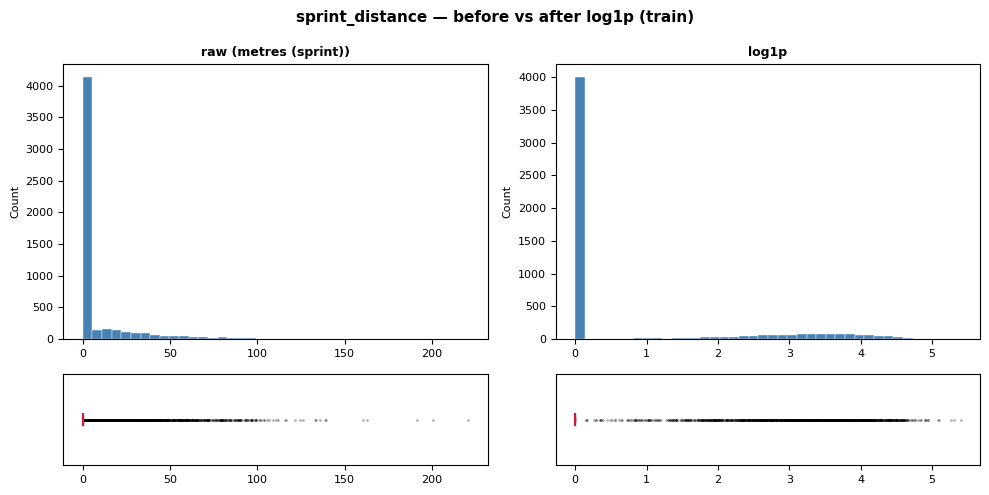

In [12]:
# 7a. sprint_distance before vs after log1p
fig_sd, axes_sd = plt.subplots(
    2, 2, figsize=(10, 5),
    gridspec_kw={'height_ratios': [3, 1]},
)
fig_sd.suptitle('sprint_distance — before vs after log1p (train)', fontsize=11, fontweight='bold')

for col_idx, (data, label) in enumerate([
    (_sd_raw_train,           'raw (metres (sprint))'),
    (train['sprint_distance'],   'log1p'),
]):
    ax_h = axes_sd[0, col_idx]
    ax_b = axes_sd[1, col_idx]

    ax_h.hist(data.dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    ax_h.set_title(label, fontsize=9, fontweight='bold')
    ax_h.set_ylabel('Count', fontsize=8)
    ax_h.tick_params(labelsize=8)

    ax_b.boxplot(
        data.dropna(), vert=False, patch_artist=True,
        boxprops    = dict(facecolor='steelblue', alpha=0.5),
        medianprops = dict(color='crimson', linewidth=1.5),
        whiskerprops= dict(linewidth=0.8),
        capprops    = dict(linewidth=0.8),
        flierprops  = dict(marker='.', markersize=2, alpha=0.3),
    )
    ax_b.set_yticks([])
    ax_b.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

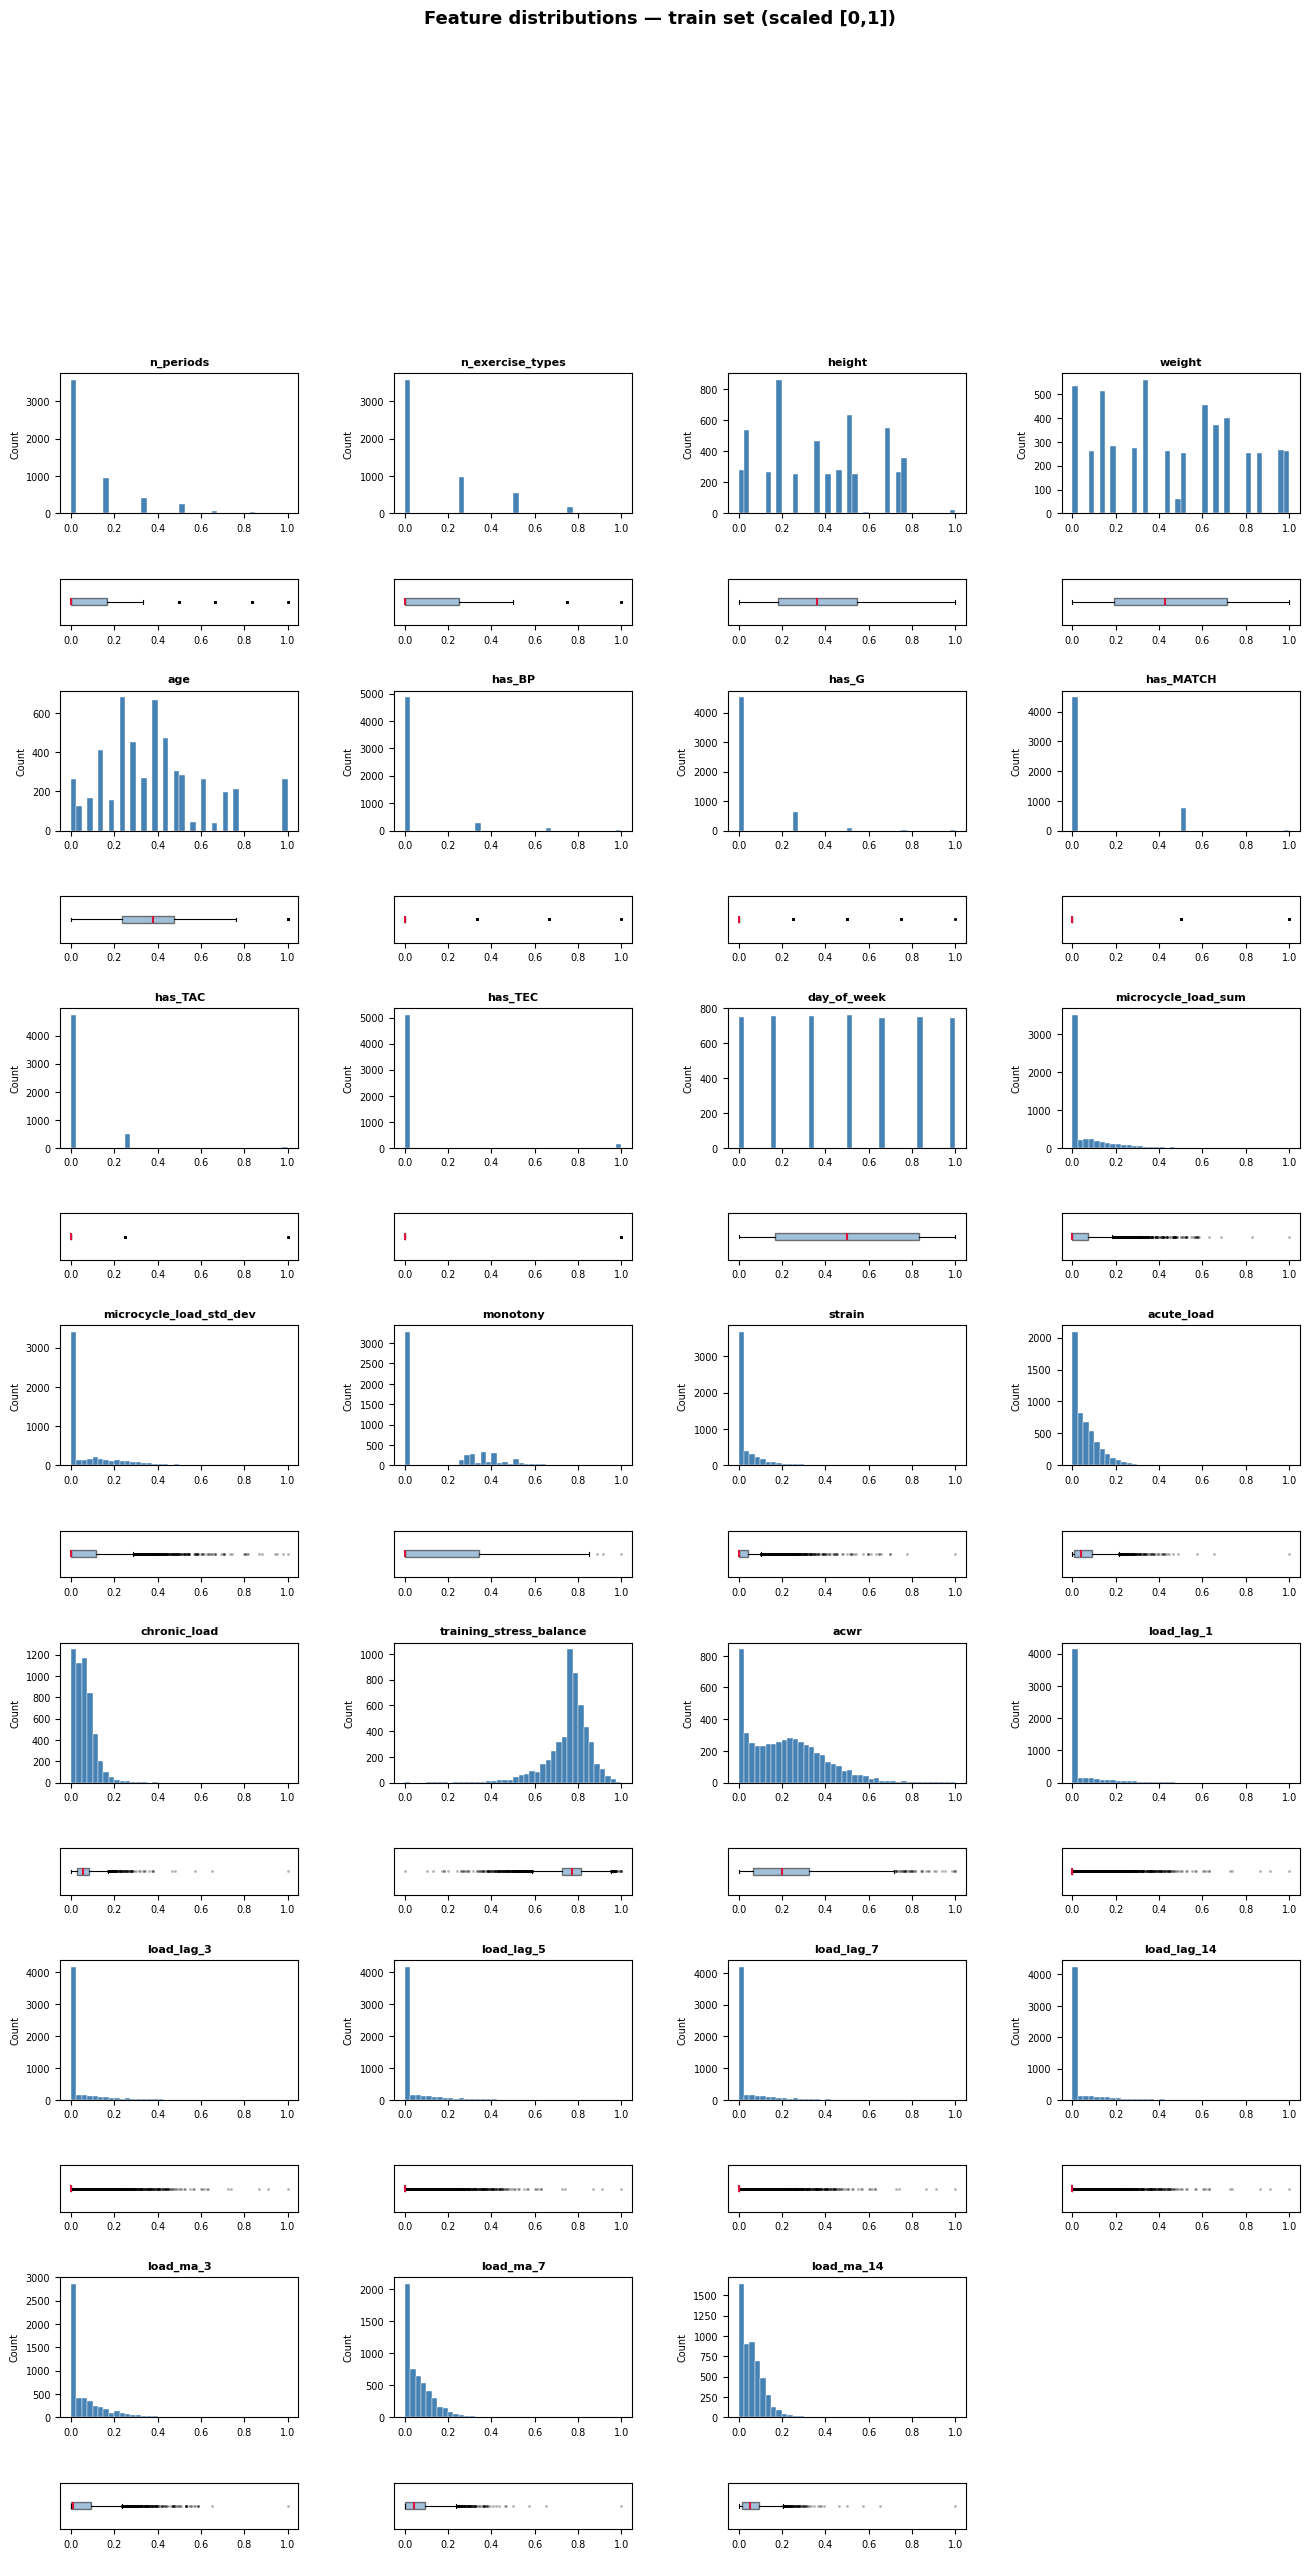

In [13]:
# 7b. All numeric feature distributions (train set)
plot_cols = [c for c in train.select_dtypes(include='number').columns if c != 'sprint_distance']

N_COLS   = 4
n_vars   = len(plot_cols)
n_groups = math.ceil(n_vars / N_COLS)

fig = plt.figure(figsize=(N_COLS * 4, n_groups * 4))
gs  = gridspec.GridSpec(
    nrows        = n_groups * 2,
    ncols        = N_COLS,
    height_ratios= [3, 1] * n_groups,
    hspace       = 0.7,
    wspace       = 0.4,
)

for i, col in enumerate(plot_cols):
    rg   = i // N_COLS
    ci   = i  % N_COLS
    data = train[col].dropna()

    ax_hist = fig.add_subplot(gs[rg * 2,     ci])
    ax_box  = fig.add_subplot(gs[rg * 2 + 1, ci])

    ax_hist.hist(data, bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    ax_hist.set_title(col, fontsize=8, fontweight='bold')
    ax_hist.set_ylabel('Count', fontsize=7)
    ax_hist.tick_params(labelsize=7)

    ax_box.boxplot(
        data, vert=False, patch_artist=True,
        boxprops    = dict(facecolor='steelblue', alpha=0.5),
        medianprops = dict(color='crimson', linewidth=1.5),
        whiskerprops= dict(linewidth=0.8),
        capprops    = dict(linewidth=0.8),
        flierprops  = dict(marker='.', markersize=2, alpha=0.3),
    )
    ax_box.set_yticks([])
    ax_box.tick_params(labelsize=7)

for i in range(n_vars, n_groups * N_COLS):
    rg = i // N_COLS
    ci = i  % N_COLS
    for row in (rg * 2, rg * 2 + 1):
        fig.add_subplot(gs[row, ci]).set_visible(False)

fig.suptitle('Feature distributions — train set (scaled [0,1])', fontsize=13, fontweight='bold', y=1.01)
plt.show()

---
# Part B — Modelling

Two-stage pipeline:
1. **Full-feature run** — LightGBM, XGBoost, and Random Forest tuned with `RandomizedSearchCV` (25 iterations) using a date-blocked, panel-safe expanding-window CV. All diagnostic plots are shown together after all models are trained.
2. **Top-5 SHAP retraining** — same procedure repeated on the 5 features with the highest mean |SHAP| value (averaged across all three full-feature models), testing whether a minimal, interpretable feature set can match full-feature performance.

### Date-Blocked Cross-Validation

A standard `KFold` or `TimeSeriesSplit` on rows is **not panel-safe** for this dataset: different players share the same dates, so a row-level split can put one player's Monday in the training fold and another player's Monday in the validation fold — effectively leaking future temporal patterns.

`date_blocked_cv` splits on **unique calendar dates** using an expanding window:
- Each fold trains on all rows whose date falls in the first `i` date-blocks.
- Each fold validates on rows in the `(i+1)`-th date-block.
- All players are guaranteed to stay on the same side of every boundary.

In [14]:
def date_blocked_cv(dates, n_splits=4):
    """
    Panel-safe expanding-window CV.
    Returns list of (train_idx, val_idx) positional index arrays.
    Splits are made on unique dates so all players stay within each block.
    """
    dates        = np.asarray(dates)
    unique_dates = np.sort(pd.unique(dates))
    blocks       = np.array_split(unique_dates, n_splits + 1)
    splits       = []
    for i in range(1, n_splits + 1):
        train_dates = np.concatenate(blocks[:i])
        val_dates   = blocks[i]
        train_idx   = np.flatnonzero(np.isin(dates, train_dates))
        val_idx     = np.flatnonzero(np.isin(dates, val_dates))
        if len(train_idx) and len(val_idx):
            splits.append((train_idx, val_idx))
    return splits

### Model Definitions & Hyperparameter Spaces

Three tree-based models are compared. Wide randomised search spaces are used for each:

| Model | Key hyperparameters searched |
|---|---|
| **LightGBM** | `n_estimators`, `learning_rate`, `num_leaves`, `max_depth`, `min_child_samples`, `subsample`, `colsample_bytree`, `reg_lambda` |
| **XGBoost** | `n_estimators`, `learning_rate`, `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `gamma`, `reg_lambda` |
| **Random Forest** | `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` |

In [15]:
def get_model_and_space(name, random_state=42):
    if name == "lightgbm":
        model = LGBMRegressor(random_state=random_state, n_jobs=-1, verbose=-1)
        space = {
            "n_estimators":      randint(200, 900),
            "learning_rate":     loguniform(1e-2, 2e-1),
            "num_leaves":        randint(15, 160),
            "max_depth":         randint(3, 14),
            "min_child_samples": randint(10, 80),
            "subsample":         uniform(0.6, 0.4),
            "colsample_bytree":  uniform(0.6, 0.4),
            "reg_lambda":        loguniform(1e-3, 10.0),
        }
    elif name == "xgboost":
        model = XGBRegressor(
            random_state=random_state, n_jobs=-1, verbosity=0, tree_method="hist"
        )
        space = {
            "n_estimators":     randint(200, 900),
            "learning_rate":    loguniform(1e-2, 2e-1),
            "max_depth":        randint(3, 12),
            "min_child_weight": randint(1, 12),
            "subsample":        uniform(0.6, 0.4),
            "colsample_bytree": uniform(0.6, 0.4),
            "gamma":            uniform(0, 5),
            "reg_lambda":       loguniform(1e-3, 10.0),
        }
    elif name == "random_forest":
        model = RandomForestRegressor(random_state=random_state, n_jobs=-1)
        space = {
            "n_estimators":      randint(200, 600),
            "max_depth":         randint(4, 24),
            "min_samples_split": randint(2, 20),
            "min_samples_leaf":  randint(1, 12),
            "max_features":      uniform(0.3, 0.7),
        }
    else:
        raise ValueError(f"Unknown model: {name}")
    return model, space


def tune_model(name, X, y, dates, n_iter=25, n_splits=4, random_state=42):
    """RandomizedSearchCV with date-blocked CV. Scores on log1p target."""
    model, space = get_model_and_space(name, random_state)
    cv = date_blocked_cv(dates, n_splits=n_splits)
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=space,
        n_iter=n_iter,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        random_state=random_state,
        refit=True,
        error_score="raise",
    )
    search.fit(X, y)
    return search


def evaluate(model, X_test, y_test_log):
    """All metrics on the original scale via expm1."""
    pred   = np.expm1(model.predict(X_test))
    actual = np.expm1(np.asarray(y_test_log))
    pred   = np.clip(pred, 0, None)
    return {
        "rmse": float(np.sqrt(mean_squared_error(actual, pred))),
        "mae":  float(mean_absolute_error(actual, pred)),
        "r2":   float(r2_score(actual, pred)),
    }

### Compute Helpers

Each helper **collects** data from a trained model without plotting. Plotting happens in a separate pass once all models have been trained, so all three models are visible side-by-side in each diagnostic figure.

- `_compute_lc` — learning curve: retrain on 20/40/60/80/100 % of training history, record train and test R² at each fraction.
- `_compute_qq` — Q-Q plot data: `scipy.stats.probplot` on log-scale residuals.
- `_compute_shap` — SHAP values: `TreeExplainer` on a 500-row sample from `X_test`; returns raw values, the sample DataFrame, and mean |SHAP| per feature.

In [16]:
def _compute_lc(name, estimator, X_tr, y_tr, dates_tr, X_te, y_te):
    """Returns (sizes, tr_r2s, te_r2s) — R² on the original scale via expm1."""
    unique_dates       = np.sort(pd.unique(dates_tr))
    fracs              = [0.2, 0.4, 0.6, 0.8, 1.0]
    tr_r2s, te_r2s, sizes = [], [], []
    for frac in fracs:
        cutoff       = unique_dates[max(int(len(unique_dates) * frac) - 1, 0)]
        mask         = pd.Series(dates_tr).values <= cutoff
        X_sub, y_sub = X_tr[mask], y_tr[mask]
        est          = clone(estimator).fit(X_sub, y_sub)
        tr_r2s.append(evaluate(est, X_sub, y_sub)["r2"])
        te_r2s.append(evaluate(est, X_te,  y_te)["r2"])
        sizes.append(int(mask.sum()))
    return sizes, tr_r2s, te_r2s


def _compute_qq(model, X_te, y_te):
    """Returns (osm, osr, slope, intercept) from probplot on log1p residuals."""
    residuals = np.asarray(y_te) - model.predict(X_te)
    (osm, osr), (slope, intercept, _) = scipy_stats.probplot(residuals)
    return osm, osr, slope, intercept


def _compute_shap(model, X_te):
    """Returns (shap_values_array, sample_df, mean_abs_series)."""
    sample      = X_te.sample(min(500, len(X_te)), random_state=42)
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(sample)
    mean_abs    = pd.Series(np.abs(shap_values.values).mean(axis=0), index=sample.columns)
    return shap_values.values, sample, mean_abs

### Subplot Plot Functions

One figure per diagnostic type, all models as side-by-side subpanels:

- **Learning curves** — R² vs training set size; shows whether the model is data-hungry or already saturated.
- **Q-Q plots** — residuals vs normal quantiles on the log1p scale; deviations indicate non-normality of errors.
- **SHAP bar chart** — mean |SHAP| per feature, top 20; comparable across all models in one figure.
- **SHAP beeswarms** — SHAP dot plots per model (shown sequentially; SHAP's API renders one figure at a time).

In [17]:
def _plot_learning_curves(lc_data):
    n    = len(lc_data)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)
    axes = axes[0]
    for ax, (name, (sizes, tr_r2s, te_r2s)) in zip(axes, lc_data.items()):
        ax.plot(sizes, tr_r2s, "o-",  label="Train", color="steelblue")
        ax.plot(sizes, te_r2s, "s--", label="Test",  color="crimson")
        ax.set_xlabel("Training samples")
        ax.set_ylabel("R²")
        ax.set_title(name, fontweight="bold")
        ax.legend()
    fig.suptitle("Learning curves (R² on original scale)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def _plot_qq_plots(qq_data):
    n    = len(qq_data)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), squeeze=False)
    axes = axes[0]
    for ax, (name, (osm, osr, slope, intercept)) in zip(axes, qq_data.items()):
        ax.scatter(osm, osr, s=4, alpha=0.4, color="steelblue", label="Residuals")
        ax.plot(osm, slope * np.array(osm) + intercept, "r-", linewidth=1.2, label="Normal ref.")
        ax.set_title(name, fontweight="bold")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Sample quantiles")
        ax.legend(fontsize=8)
    fig.suptitle("Q-Q plots of residuals (log1p scale)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def _plot_shap_bars(shap_data):
    n    = len(shap_data)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), squeeze=False)
    axes = axes[0]
    for ax, (name, entry) in zip(axes, shap_data.items()):
        mean_abs = entry[2]
        top20    = mean_abs.nlargest(20).iloc[::-1]
        ax.barh(range(len(top20)), top20.values, color="steelblue")
        ax.set_yticks(range(len(top20)))
        ax.set_yticklabels(top20.index, fontsize=7)
        ax.set_xlabel("Mean |SHAP|")
        ax.set_title(name, fontweight="bold")
    fig.suptitle("SHAP feature importance (mean |SHAP| on test set)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def _plot_shap_beeswarms(shap_data):
    for name, (shap_vals, sample, _) in shap_data.items():
        shap.summary_plot(shap_vals, sample, feature_names=list(sample.columns),
                          plot_type="dot", max_display=20, show=False)
        plt.title(f"SHAP beeswarm — {name}", fontweight="bold")
        plt.tight_layout()
        plt.show()

### `run_comparison` — Driver Function

Orchestrates the full training loop:
1. For each model: tune with `RandomizedSearchCV`, evaluate on train and test, collect learning-curve / Q-Q / SHAP data.
2. After all models: show RMSE comparison bar chart, then all diagnostic subplots.
3. Return `results` DataFrame, fitted searches, and SHAP data (used for top-5 feature selection).

In [18]:
def run_comparison(
    train, test, feature_cols, target, model_dir,
    models=("lightgbm", "xgboost", "random_forest"),
    n_iter=25, n_splits=4, random_state=42
):
    train = train.reset_index(drop=True)
    X_tr, y_tr = train[feature_cols], train[target]
    X_te, y_te = test[feature_cols],  test[target]

    rows, fitted                = [], {}
    lc_data, qq_data, shap_data = {}, {}, {}

    for name in tqdm(models, desc="Training models"):
        search = tune_model(name, X_tr, y_tr, train["date"].values,
                            n_iter=n_iter, n_splits=n_splits, random_state=random_state)
        est = search.best_estimator_

        tr_m     = evaluate(est, X_tr, y_tr)
        te_m     = evaluate(est, X_te, y_te)
        val_rmse = float(np.sqrt(-search.best_score_))   # log1p scale

        rows.append({
            "model":      name,
            "train_rmse": tr_m["rmse"], "train_mae": tr_m["mae"], "train_r2": tr_m["r2"],
            "val_rmse*":  val_rmse,
            "test_rmse":  te_m["rmse"], "test_mae":  te_m["mae"], "test_r2":  te_m["r2"],
        })
        fitted[name] = search
        joblib.dump(est, model_dir / f"{name}_best.joblib")

        lc_data[name]   = _compute_lc(name, est, X_tr, y_tr, train["date"].values, X_te, y_te)
        qq_data[name]   = _compute_qq(est, X_te, y_te)
        shap_data[name] = _compute_shap(est, X_te)

    results = pd.DataFrame(rows).sort_values("test_rmse").reset_index(drop=True)
    results.to_csv(model_dir / "model_comparison.csv", index=False)

    # RMSE comparison bar chart
    x     = np.arange(len(results))
    width = 0.25
    _, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width, results["train_rmse"], width, label="Train",       color="steelblue")
    ax.bar(x,         results["val_rmse*"],  width, label="Val (log1p)", color="orange")
    ax.bar(x + width, results["test_rmse"],  width, label="Test",        color="crimson")
    ax.set_xticks(x)
    ax.set_xticklabels(results["model"], fontsize=10)
    ax.set_ylabel("RMSE  (metres (sprint); val on log scale)")
    ax.set_title("Model comparison — Train / Val / Test RMSE", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # All diagnostic plots after all models trained
    _plot_learning_curves(lc_data)
    _plot_qq_plots(qq_data)
    _plot_shap_bars(shap_data)
    _plot_shap_beeswarms(shap_data)

    return results, fitted, shap_data

## 8. Full-Feature Run

All three models are trained on the complete feature set. Progress is tracked with `tqdm`. After training, four diagnostic figures are shown:

1. **RMSE comparison bar** — Train / Val (log scale) / Test RMSE for all models.
2. **Learning curves** — R² vs training set size (expanding history).
3. **Q-Q plots** — normality of residuals on the log1p scale.
4. **SHAP bars + beeswarms** — feature importance and direction of effect.

Training models:   0%|          | 0/3 [00:00<?, ?it/s]

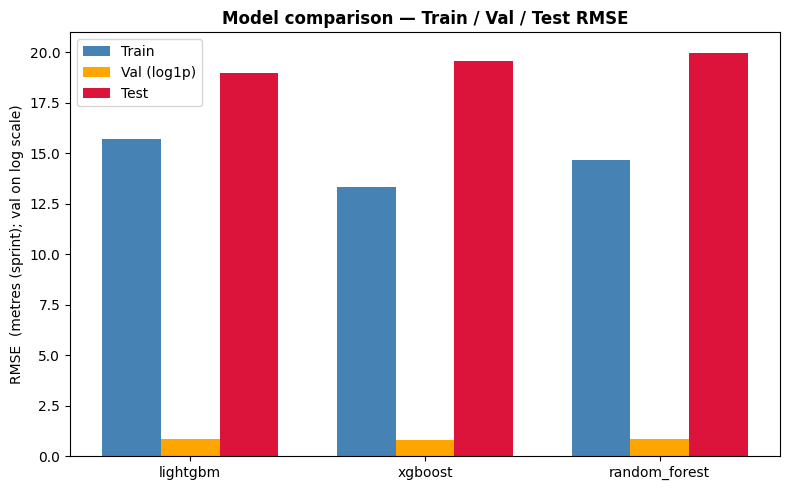

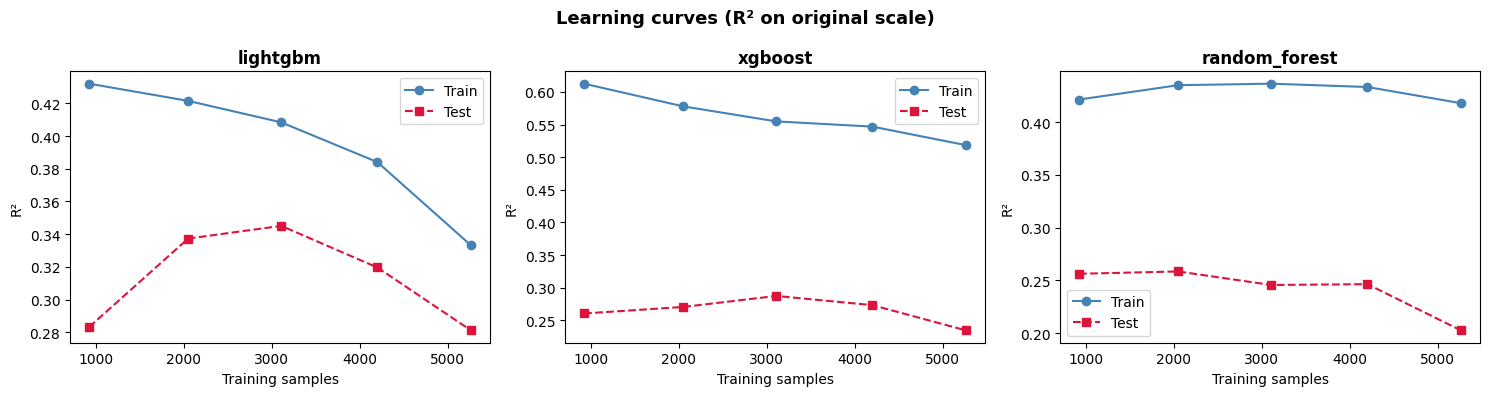

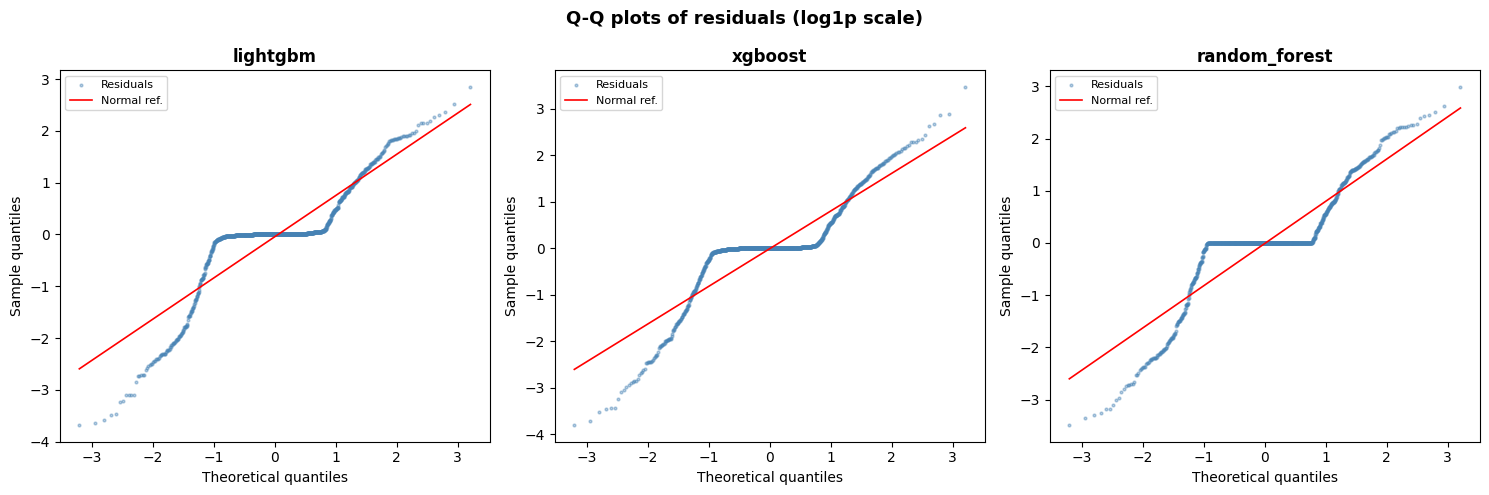

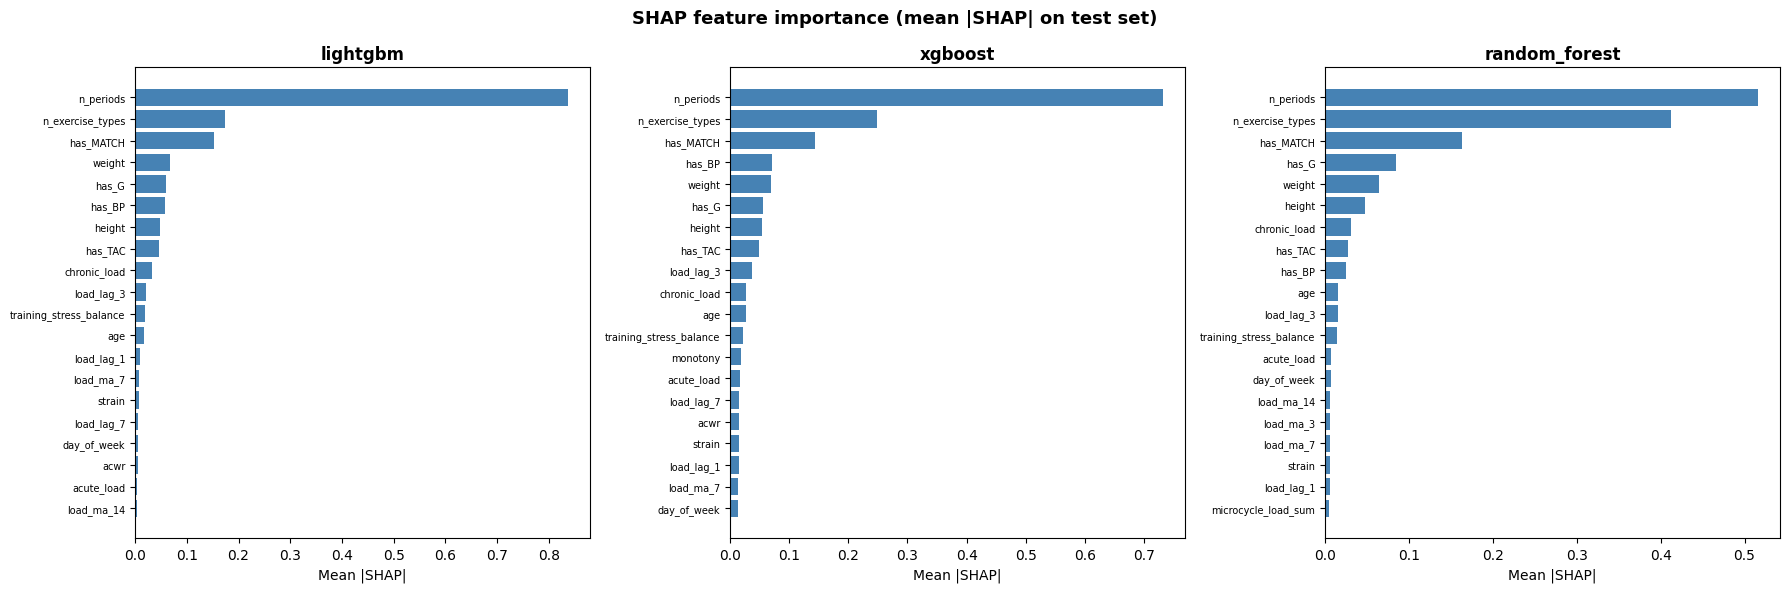

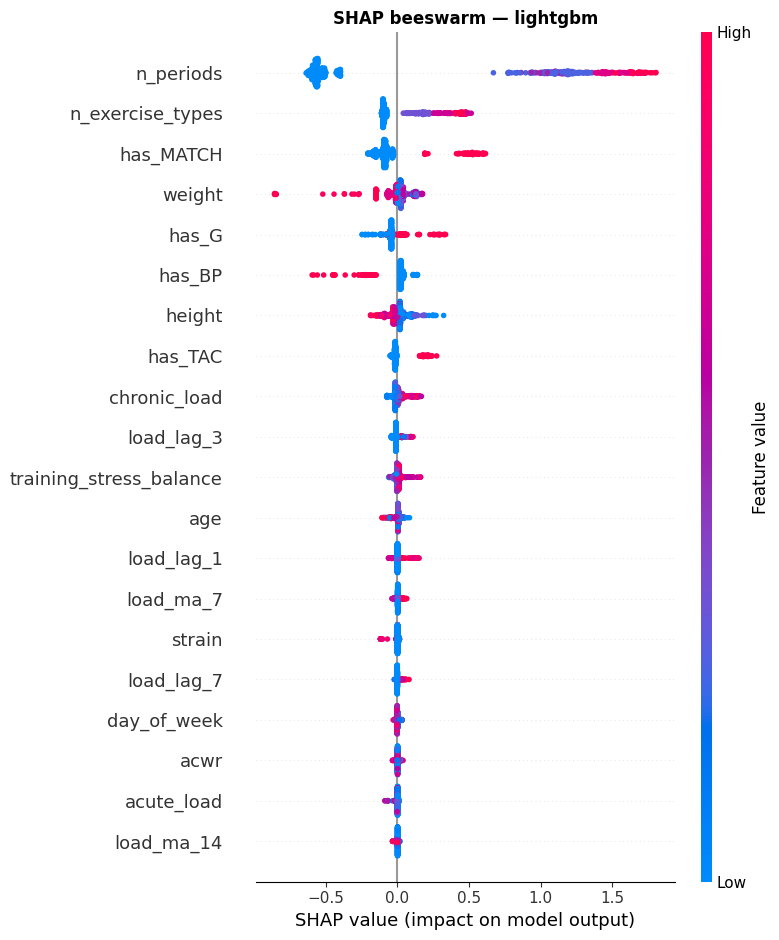

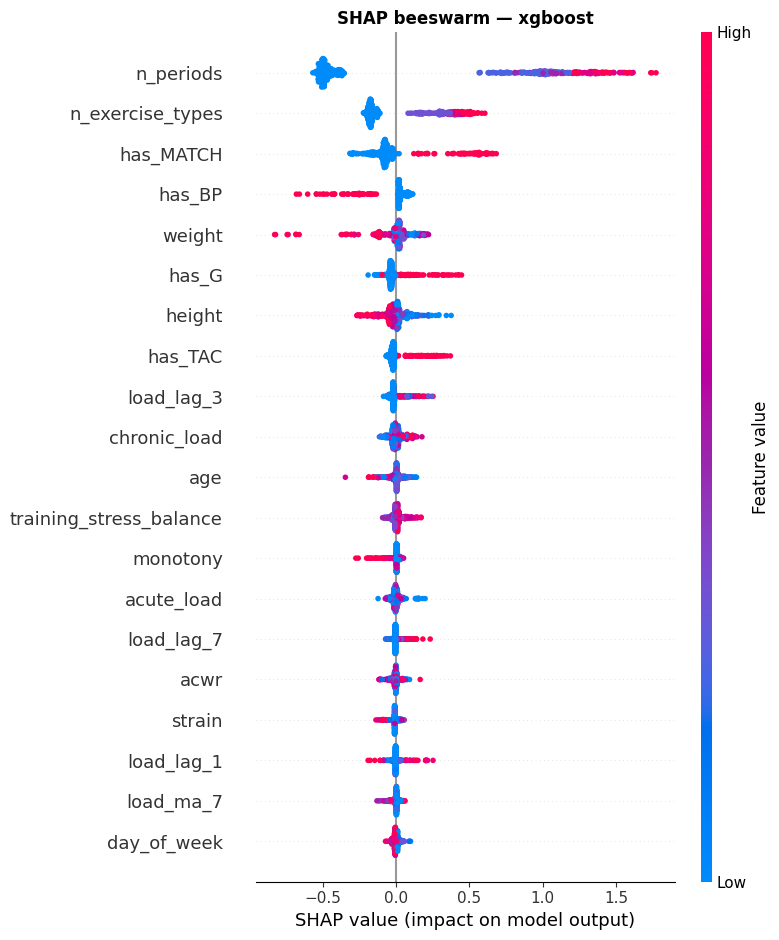

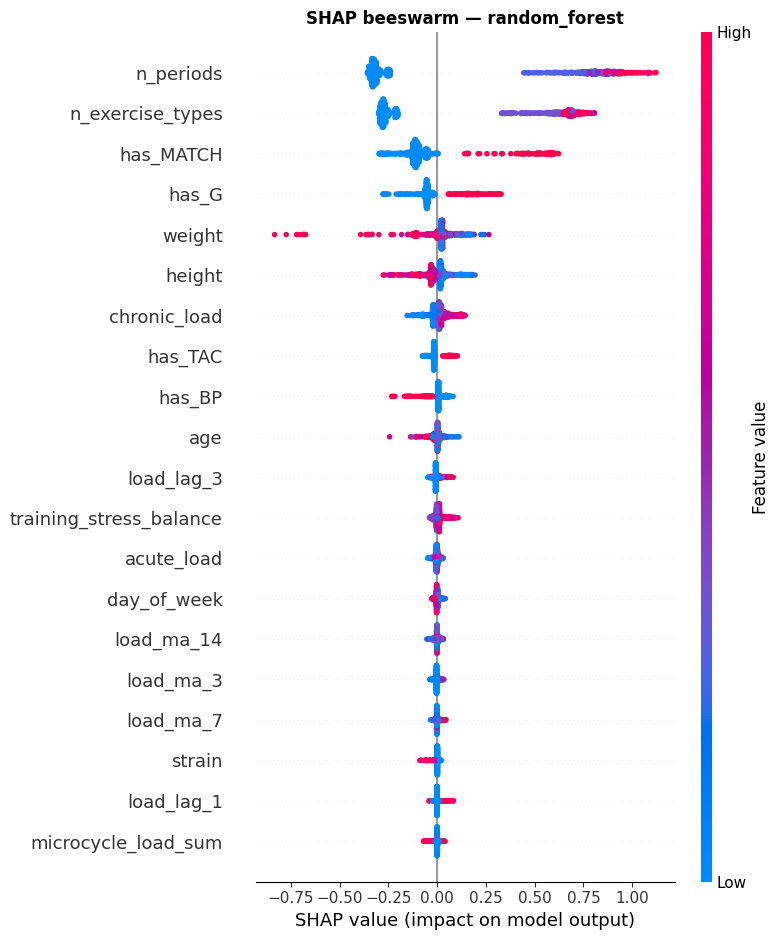

In [19]:
results, fitted, shap_data = run_comparison(
    train, test, feature_cols, TARGET, MODEL_DIR
)

## 9. Top-5 SHAP Retraining

The mean |SHAP| values from the full-feature run are averaged across all three models to produce a consensus feature ranking. The top-5 features are selected, and all three models are **retrained from scratch** on this minimal set using identical tuning settings.

**Why this matters:**
- A 5-feature model is far more interpretable for coaches and practitioners.
- If performance is comparable to the full-feature model, simpler data collection is sufficient in production.
- If performance drops significantly, the additional features are adding meaningful information.

> `val_rmse*` is on the log1p scale; all other metrics are in metres.

In [20]:
# Consensus feature ranking: average mean |SHAP| across all three models
mean_abs_all = pd.DataFrame({n: shap_data[n][2] for n in shap_data}).mean(axis=1)
top5         = mean_abs_all.nlargest(5).index.tolist()

print("Feature ranking (mean |SHAP|, averaged across LightGBM / XGBoost / RF):")
print(mean_abs_all.sort_values(ascending=False).round(4).to_string())
print(f"\n\u2192 Top-5 selected: {top5}")

Feature ranking (mean |SHAP|, averaged across LightGBM / XGBoost / RF):
n_periods                  0.6957
n_exercise_types           0.2782
has_MATCH                  0.1533
weight                     0.0667
has_G                      0.0666
has_BP                     0.0513
height                     0.0498
has_TAC                    0.0411
chronic_load               0.0301
load_lag_3                 0.0243
age                        0.0197
training_stress_balance    0.0184
load_lag_1                 0.0099
acute_load                 0.0094
strain                     0.0091
load_ma_7                  0.0089
monotony                   0.0085
load_lag_7                 0.0083
day_of_week                0.0082
acwr                       0.0082
load_ma_14                 0.0073
microcycle_load_sum        0.0068
microcycle_load_std_dev    0.0060
load_ma_3                  0.0058
load_lag_5                 0.0048
load_lag_14                0.0047
has_TEC                    0.0039

→ Top-5 s

Training models:   0%|          | 0/3 [00:00<?, ?it/s]

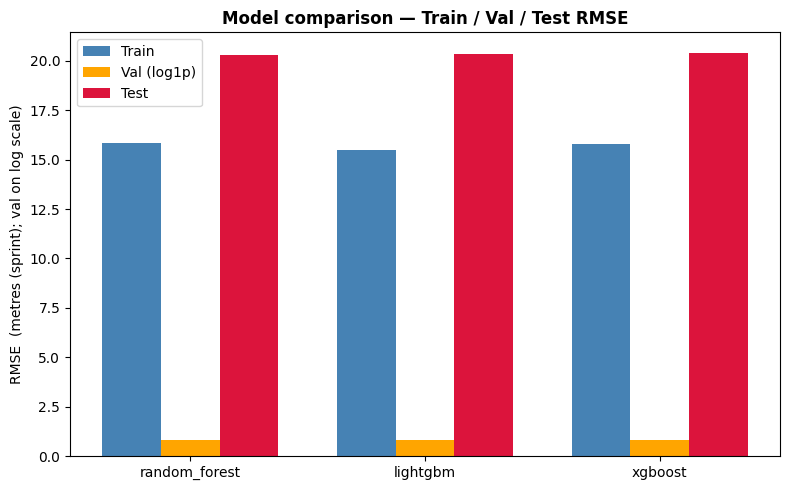

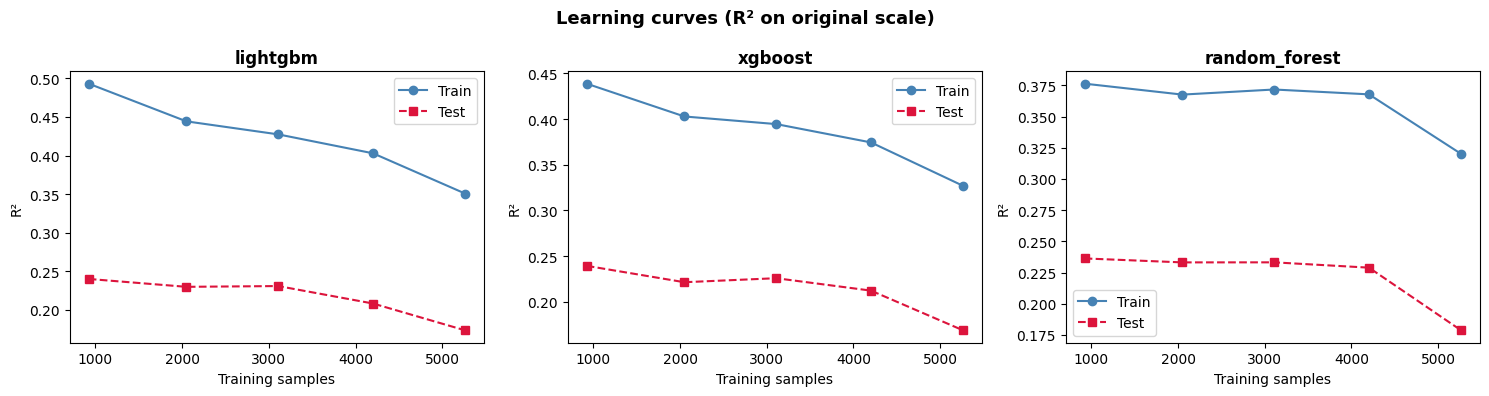

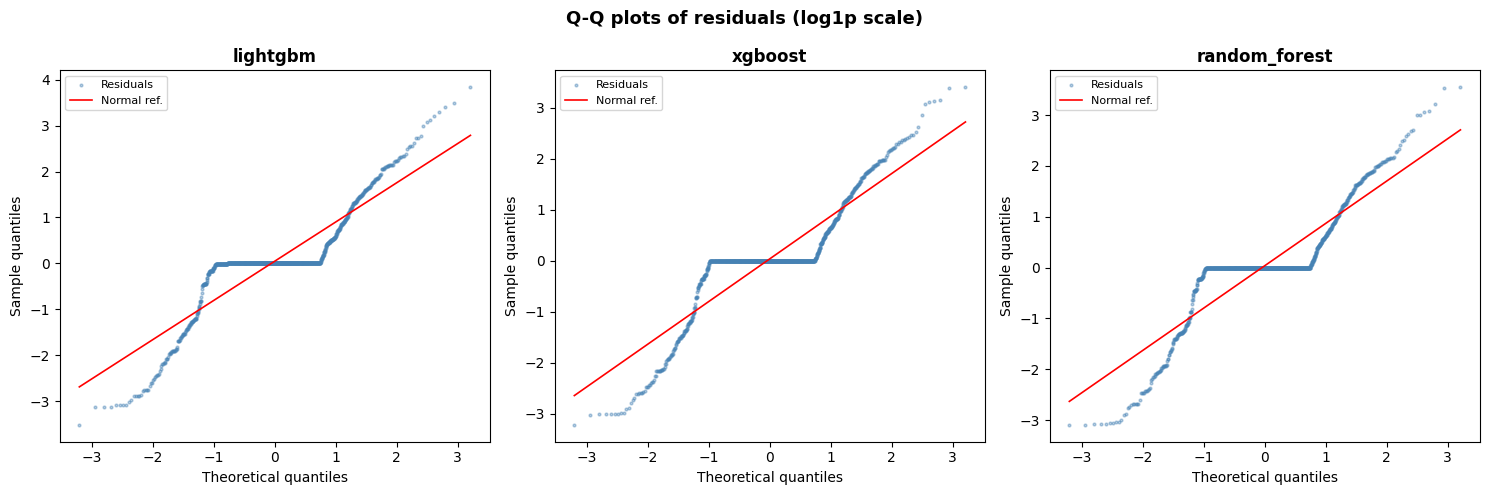

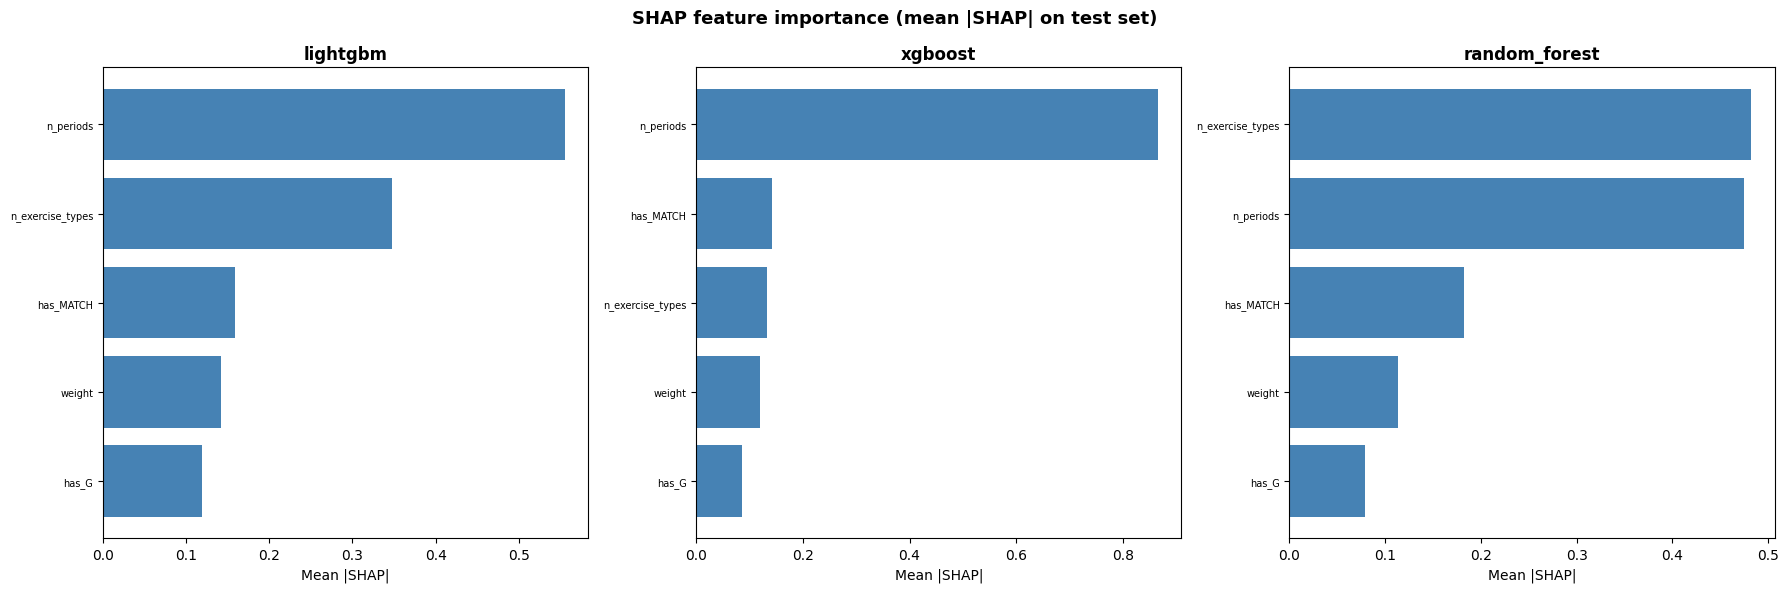

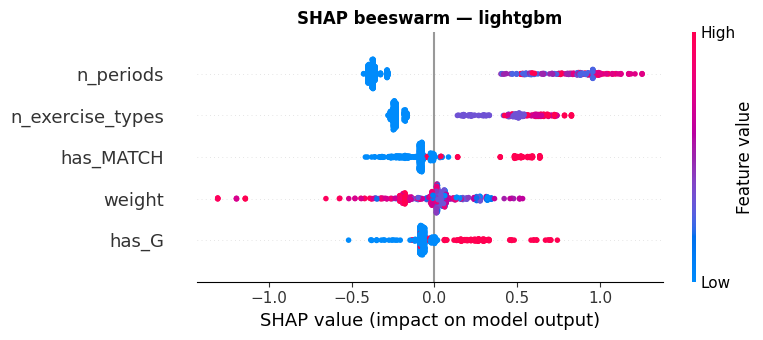

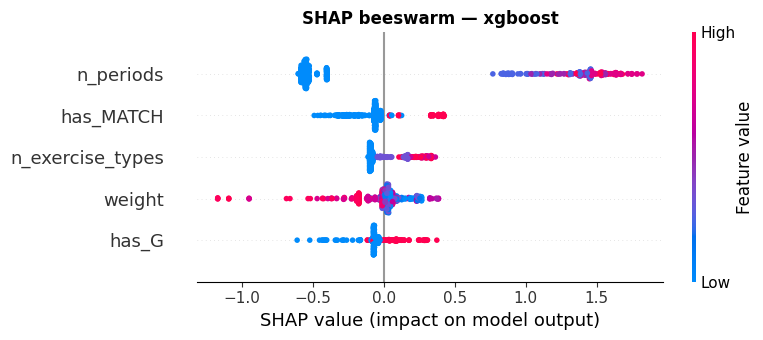

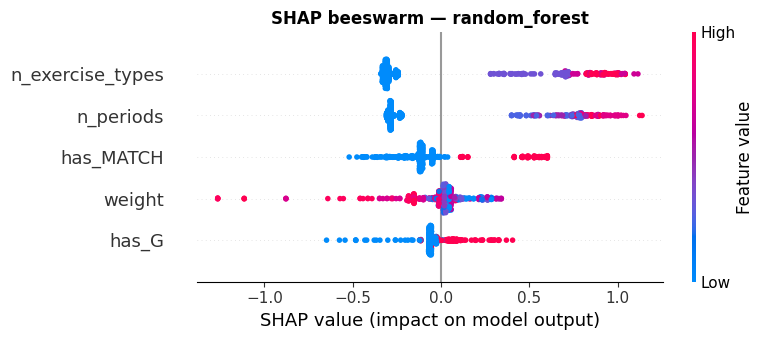

In [21]:
results_5, fitted_5, _ = run_comparison(
    train, test, top5, TARGET, MODEL_DIR
)

## 10. Final Results

Side-by-side comparison of all models on the full feature set and the top-5 SHAP feature set. Key columns:

| Column | Description |
|---|---|
| `train_rmse / mae / r2` | Training-set metrics in original metres (sprint) |
| `val_rmse*` | Best CV RMSE on **log1p scale** (not original units) |
| `test_rmse / mae / r2` | Hold-out test metrics in original metres (sprint) |

A model generalises well when `train_r2 ≈ test_r2` and `test_rmse` is competitive with the lower-variance full-feature model.

In [22]:
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("─" * 60)
print("Full features")
print("─" * 60)
print("  * val_rmse* is on the log1p(sprint_distance) scale; all other metrics are in metres (sprint).\n")
print(results.to_string(index=False))

print("\n" + "─" * 60)
print(f"Top-5 SHAP features: {top5}")
print("─" * 60)
print(results_5.to_string(index=False))

## 11. Save Forecast Bundle


In [23]:
bundle = {
    "model":        fitted["xgboost"].best_estimator_,
    "scaler":       scaler,
    "feature_cols": feature_cols,
    "ewma_spans":   {"acute": 7, "chronic": 28},
}

bundle_path = MODEL_DIR / "forecast_bundle.joblib"
joblib.dump(bundle, bundle_path)

# Verify round-trip
loaded = joblib.load(bundle_path)
assert loaded["feature_cols"] == feature_cols
assert list(loaded["ewma_spans"].keys()) == ["acute", "chronic"]
print(f"Saved: {bundle_path}")
print(f"  model:        {type(loaded['model']).__name__}")
print(f"  scaler:       {type(loaded['scaler']).__name__}")
print(f"  feature_cols: {len(loaded['feature_cols'])} features")
print(f"  ewma_spans:   {loaded['ewma_spans']}")
print(f"  file size:    {bundle_path.stat().st_size / 1024:.1f} KB")

Saved: /Users/rishirajsinharay/Desktop/demo/models/notebook_experiments/sprint_distance/forecast_bundle.joblib
  model:        XGBRegressor
  scaler:       MinMaxScaler
  feature_cols: 27 features
  ewma_spans:   {'acute': 7, 'chronic': 28}
  file size:    917.9 KB


## 12. Recursive Forecast

`recursive_forecast` predicts `sprint_distance` for each (player, date) in `plan` one day at a time, writing each day's prediction into `sprint_distance` before advancing to the next day. This "closed-loop" approach is what makes temporal features (EWMA, lags, rolling MAs) correct for future days — each step sees a fully consistent history.

### Inputs

| Argument | Schema | Notes |
|---|---|---|
| `bundle` | dict from `forecast_bundle.joblib` | model, scaler, feature_cols, ewma_spans |
| `history` | DataFrame, same columns as `daily` pre-feature-engineering | Real past rows; must extend far enough back to seed the longest lag (14 days) and EWMA (28 days) |
| `plan` | DataFrame, same columns; `sprint_distance = NaN`; rest days `n_periods = 0` | Plan-known columns filled: `n_periods`, `n_exercise_types`, `has_*`, `height`, `weight`, `age` |

### Algorithm (per date in sorted order)

1. Concat `history` + `plan_work` (plan with predictions filled so far).
2. Run `_add_features` on the full combined frame — all shift(1) guards are already baked in, so future NaNs never pollute current-day features.
3. Extract rows for `current_date`; scale with `bundle["scaler"]`; predict; `expm1`; clip at 0.
4. Force predicted value to **0** for rest days (`n_periods == 0`).
5. Write the prediction back into `plan_work["sprint_distance"]` for `current_date` — the next iteration's `_add_features` call will see it as true history.

Predictions are written back **by `player_id`** (not by positional index) so reordering inside `_add_features` can never silently misalign a player's value.

In [24]:
def recursive_forecast(bundle, history, plan):
    """
    Recursively predict sprint_distance for each (player, date) in plan,
    then compute reported ACWR over the combined real + predicted series.

    Parameters
    ----------
    bundle : dict
        Loaded from forecast_bundle.joblib.  Keys: model, scaler,
        feature_cols, ewma_spans.
    history : pd.DataFrame
        Real daily rows in the same schema as `daily` (post Section 3.1,
        pre feature engineering).  Must cover at least the 28 days prior
        to plan's first date so chronic_load seeds correctly.
    plan : pd.DataFrame
        Next N daily rows per player.  Plan-known columns are filled;
        sprint_distance must be NaN; rest days have n_periods == 0.

    Returns
    -------
    pd.DataFrame  [player_id, date, predicted_sprint_distance,
                   acute, chronic, acwr]
        Only the future (plan) dates are returned.
    """
    model        = bundle["model"]
    scaler       = bundle["scaler"]
    feature_cols = bundle["feature_cols"]

    # Working copy — sprint_distance starts NaN; filled one date at a time
    plan_work = plan.copy()
    plan_work["sprint_distance"] = np.nan

    for current_date in sorted(plan_work["date"].unique()):
        # Full history visible to _add_features at this step
        combined   = pd.concat([history, plan_work], ignore_index=True)
        featurized = _add_features(combined)

        day_rows = featurized[featurized["date"] == current_date].copy()

        # Scale → predict → clip at 0
        X_scaled = scaler.transform(day_rows[feature_cols])
        pred_m   = np.clip(np.expm1(model.predict(X_scaled)), 0, None)

        # Rest days produce 0 distance regardless of model output
        pred_m[day_rows["n_periods"].values == 0] = 0.0

        # Write back by player_id — safe against any internal reordering in
        # _add_features (which sorts by player_id, date and resets the index)
        for pid, val in zip(day_rows["player_id"].values, pred_m):
            plan_work.loc[
                (plan_work["date"] == current_date) & (plan_work["player_id"] == pid),
                "sprint_distance",
            ] = val

    # -------------------------------------------------------------------------
    # Reported ACWR — computed on the combined real + predicted series,
    # INCLUDING the current day (no shift).
    #
    # This is intentionally different from the shifted `acwr` feature used
    # during training: that version excludes today's load with shift(1) to
    # prevent the target from leaking into its own feature.  Here we want the
    # value a practitioner would read on their monitoring dashboard *after* the
    # session has been completed (or forecast), so today's distance is included.
    # -------------------------------------------------------------------------
    full = (
        pd.concat([history, plan_work], ignore_index=True)
        .sort_values(["player_id", "date"])
        .reset_index(drop=True)
    )

    full["acute"]   = full.groupby("player_id", observed=True)["sprint_distance"].transform(
        lambda s: s.ewm(span=7,  min_periods=1).mean()
    )
    full["chronic"] = full.groupby("player_id", observed=True)["sprint_distance"].transform(
        lambda s: s.ewm(span=28, min_periods=1).mean()
    )
    # Avoid division by zero on the very first day of a player's history
    full["acwr"] = full["acute"] / full["chronic"].replace(0, np.nan)

    future_dates = plan_work["date"].unique()
    return (
        full[full["date"].isin(future_dates)]
        [["player_id", "date", "sprint_distance", "acute", "chronic", "acwr"]]
        .rename(columns={"sprint_distance": "predicted_sprint_distance"})
        .sort_values(["player_id", "date"])
        .reset_index(drop=True)
    )

## 13. Forecast Input Helpers

Two helpers that produce the exact frames `recursive_forecast` expects.

---

### `build_history(daily, n_days=90)`

Slices the last `n_days` **calendar days** per player out of `daily`.

**Why ≥ 90?**  The longest temporal dependency is `chronic_load` (28-day EWMA). The EWMA is initialised from the first available value and decays geometrically, so it becomes unreliable if history is shorter than a few half-lives. 90 days gives ≈ 3 EWMA half-lives before the first forecast day, which is enough for a stable chronic baseline. The remaining buffer also covers the 14-day lag feature and any gaps introduced by rest days.

---

### `build_plan(coach_plan)`

Converts a coach's raw session schedule into the schema that `recursive_forecast` expects.  Reads the canonical `has_*` column names and each player's latest `height` / `weight` / `age` / `position` from the notebook-scoped `daily` frame.

`coach_plan` must contain four columns:

| Column | Type | Notes |
|---|---|---|
| `player_id` | same dtype as `daily` | |
| `date` | any pandas-parseable | |
| `exercise_types` | `list` / `set` of strings, e.g. `["TAC", "G"]` | empty list or `None` → rest day |
| `n_periods` | `int` | overridden to `0` when `exercise_types` is empty |

Consistency is enforced in both directions: an empty `exercise_types` sets `n_periods = 0`, and `n_periods == 0` clears `exercise_types` to `[]`. `age` is taken from each player's most recent row in `daily` — accurate enough for a 15-day forecast horizon.

In [25]:
def build_history(daily, n_days=90):
    """
    Return the last n_days calendar days per player from the daily frame.

    Parameters
    ----------
    daily  : pd.DataFrame  post-Section-3.1 frame (pre feature engineering)
    n_days : int           calendar days to retain per player (>= 90 recommended)

    Returns
    -------
    pd.DataFrame  same schema as daily, one contiguous window per player
    """
    if n_days < 90:
        import warnings
        warnings.warn(
            f"n_days={n_days} may be too short to seed chronic_load reliably "
            "(28-day EWMA needs >= 90 days for a stable baseline).",
            UserWarning, stacklevel=2,
        )
    player_max = daily.groupby("player_id", observed=True)["date"].transform("max")
    cutoff     = player_max - pd.Timedelta(days=n_days - 1)
    return (
        daily[daily["date"] >= cutoff]
        .copy()
        .sort_values(["player_id", "date"])
        .reset_index(drop=True)
    )


def build_plan(coach_plan):
    """
    Convert a coach's session schedule into a plan frame for recursive_forecast.

    Reads has_* column names and player profiles from the notebook-scoped
    `daily` DataFrame (post Section 3.1, pre feature engineering).

    Parameters
    ----------
    coach_plan : pd.DataFrame
        Required columns:
          player_id      – same IDs as in daily
          date           – session date (any pandas-parseable format)
          exercise_types – list/set of exercise-type strings, e.g. ["TAC", "G"];
                           empty list or None marks a rest day
          n_periods      – int; overridden to 0 for rest days

    Returns
    -------
    pd.DataFrame  same schema as daily (pre feature engineering):
        player_id, date, sprint_distance (NaN), n_periods, n_exercise_types,
        has_*, height, weight, age, position — sorted by (player_id, date)
    """
    # Derive canonical has_* column names and exercise-type strings from daily
    has_cols = sorted(c for c in daily.columns if c.startswith("has_"))
    et_names = [c[len("has_"):] for c in has_cols]

    plan = coach_plan[["player_id", "date", "exercise_types", "n_periods"]].copy()
    plan["date"] = pd.to_datetime(plan["date"])

    # Normalise exercise_types: None / NaN / non-iterable → empty list
    plan["exercise_types"] = plan["exercise_types"].apply(
        lambda x: list(x) if isinstance(x, (list, set, frozenset)) else []
    )

    # Enforce consistency in both directions:
    #   empty exercise_types → rest day (n_periods = 0)
    #   n_periods == 0       → clear exercise_types to []
    plan["n_periods"] = plan.apply(
        lambda r: 0 if not r["exercise_types"] else int(r["n_periods"]), axis=1
    )
    plan["exercise_types"] = plan.apply(
        lambda r: [] if r["n_periods"] == 0 else r["exercise_types"], axis=1
    )

    # has_* binary flags derived from the scheduled exercise types
    for col, et in zip(has_cols, et_names):
        plan[col] = plan["exercise_types"].apply(lambda ets, e=et: int(e in ets))

    # Number of distinct exercise types scheduled that day (0 on rest days)
    plan["n_exercise_types"] = plan["exercise_types"].apply(lambda ets: len(set(ets)))

    # Carry each player's latest static profile from daily.
    # age is taken from the most recent row — close enough for a 15-day horizon.
    profile = (
        daily.sort_values("date")
        .groupby("player_id", observed=True)[["height", "weight", "age", "position"]]
        .last()
        .reset_index()
    )
    plan = plan.merge(profile, on="player_id", how="left")

    # Target is unknown for all future days
    plan["sprint_distance"] = np.nan

    col_order = (
        ["player_id", "date", "sprint_distance", "n_periods", "n_exercise_types"]
        + has_cols
        + ["height", "weight", "age", "position"]
    )
    return (
        plan.drop(columns=["exercise_types"])[col_order]
        .sort_values(["player_id", "date"])
        .reset_index(drop=True)
    )

## 14. Forecast Validation

Two checks verify the forecast pipeline before it is used in production.

---

### Check 1 — Skew / Smoke Test

Runs **one recursive step** on the most recent real day and asserts the result is bit-for-bit identical to the direct path:

```
pd.concat([history, plan_row]) → _add_features → scaler.transform → expm1(model.predict)
```

If the two paths diverge, the concat, `_add_features` call, scaler indexing, or `expm1` inversion inside `recursive_forecast` is wired incorrectly. Max |direct − recursive| should be floating-point zero (threshold: 1e-6 m).

---

### Check 2 — 15-Day Recursive Backtest

Picks a 15-day window inside the data with known outcomes, runs `recursive_forecast` using **only data before that window** as history and the **actual session plan** as input, then compares predictions against ground truth.

Two metric pairs are reported:

| Metric | Unit | What it measures |
|---|---|---|
| `sprint_distance` RMSE / MAE | metres | Raw load prediction error per player-day |
| ACWR RMSE / MAE | dimensionless | Error in the derived risk indicator (EWMA ratio) |

ACWR error is typically smaller than load error because the EWMA smooths individual day mistakes; a large ACWR RMSE relative to the load RMSE would indicate systematic directional bias in the predictions.

In [26]:
# =============================================================================
# CHECK 1 — Skew / smoke test
# One recursive step must match the direct _add_features + scale + predict path.
# =============================================================================
_model        = bundle["model"]
_scaler       = bundle["scaler"]
_feature_cols = bundle["feature_cols"]

_last_date = daily["date"].max()
_hist_chk  = daily[daily["date"] <  _last_date].copy().reset_index(drop=True)
_plan_chk  = daily[daily["date"] == _last_date].copy().reset_index(drop=True)
_plan_chk["sprint_distance"] = np.nan

# Direct path: concat → _add_features → scale → predict → clip
_feat_chk = _add_features(pd.concat([_hist_chk, _plan_chk], ignore_index=True))
_day_chk  = _feat_chk[_feat_chk["date"] == _last_date].copy()
_X_dir    = _scaler.transform(_day_chk[_feature_cols])
_pred_dir = np.clip(np.expm1(_model.predict(_X_dir)), 0, None)
_pred_dir[_day_chk["n_periods"].values == 0] = 0.0

# Recursive path: same inputs through recursive_forecast
_rf_chk = recursive_forecast(bundle, _hist_chk, _plan_chk)

# Align by player_id (str-cast avoids categorical dtype mismatch)
_dir_df = pd.DataFrame({
    "player_id":   _day_chk["player_id"].astype(str).values,
    "pred_direct": _pred_dir,
})
_rf_df = _rf_chk[["player_id", "predicted_sprint_distance"]].copy()
_rf_df["player_id"] = _rf_df["player_id"].astype(str)

_cmp_chk  = _dir_df.merge(_rf_df, on="player_id", how="inner")
_max_diff = (_cmp_chk["pred_direct"] - _cmp_chk["predicted_sprint_distance"]).abs().max()

assert _max_diff < 1e-6, f"Skew check FAILED: max abs diff = {_max_diff:.6e}"
print(
    f"Skew check PASSED — max |direct − recursive| = {_max_diff:.2e}  "
    f"(date {_last_date.date()}, {len(_cmp_chk)} players)"
)

Skew check PASSED — max |direct − recursive| = 0.00e+00  (date 2025-06-26, 13 players)


Backtest window : 2025-03-15 → 2025-03-29
Players / rows  : 19 / 285

Metric                              RMSE         MAE
────────────────────────────────────────────────────
sprint distance (metres (sprint))         9.7         3.0
ACWR                              0.2739      0.1198


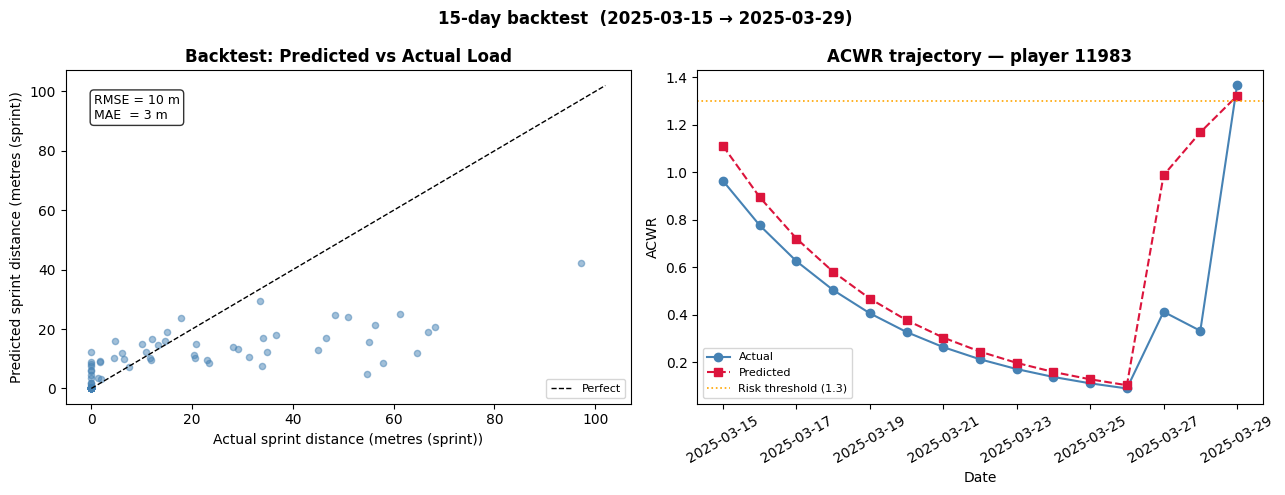

In [27]:
# =============================================================================
# CHECK 2 — 15-day recursive backtest with known actuals
# =============================================================================
_all_dates = np.sort(daily["date"].unique())
_n_d       = len(_all_dates)

# Pick 15 consecutive dates starting at the 70 % mark (well inside training)
_win_start = _all_dates[int(_n_d * 0.70)]
_win_dates = _all_dates[_all_dates >= _win_start][:15]
_win_end   = _win_dates[-1]

# Restrict to players that have real history before the window
_players_with_hist = daily[daily["date"] < _win_start]["player_id"].unique()

_bt_hist = (
    daily[(daily["date"] < _win_start) & (daily["player_id"].isin(_players_with_hist))]
    .copy().reset_index(drop=True)
)
_bt_actuals = (
    daily[(daily["date"].isin(_win_dates)) & (daily["player_id"].isin(_players_with_hist))]
    .copy().reset_index(drop=True)
)
_bt_plan = _bt_actuals.copy()
_bt_plan["sprint_distance"] = np.nan

_bt_preds = recursive_forecast(bundle, _bt_hist, _bt_plan)

# ── Load metrics ──────────────────────────────────────────────────────────────
_merged = (
    _bt_preds
    .merge(
        _bt_actuals[["player_id", "date", "sprint_distance"]],
        on=["player_id", "date"], how="inner",
    )
    .rename(columns={"sprint_distance": "actual_sprint_distance"})
)
_load_rmse = float(np.sqrt(mean_squared_error(_merged["actual_sprint_distance"],
                                               _merged["predicted_sprint_distance"])))
_load_mae  = float(mean_absolute_error(_merged["actual_sprint_distance"],
                                        _merged["predicted_sprint_distance"]))

# ── Actual ACWR — same no-shift formula as recursive_forecast, on real data ───
_full_act = (
    pd.concat([_bt_hist, _bt_actuals], ignore_index=True)
    .sort_values(["player_id", "date"]).reset_index(drop=True)
)
_full_act["_acute_a"]   = _full_act.groupby("player_id", observed=True)["sprint_distance"].transform(
    lambda s: s.ewm(span=7,  min_periods=1).mean()
)
_full_act["_chronic_a"] = _full_act.groupby("player_id", observed=True)["sprint_distance"].transform(
    lambda s: s.ewm(span=28, min_periods=1).mean()
)
_full_act["acwr_actual"] = (
    _full_act["_acute_a"] / _full_act["_chronic_a"].replace(0, np.nan)
)

_acwr_act_win = (
    _full_act[_full_act["date"].isin(_win_dates)]
    [["player_id", "date", "acwr_actual"]]
)
_acwr_cmp = (
    _bt_preds[["player_id", "date", "acwr"]]
    .merge(_acwr_act_win, on=["player_id", "date"], how="inner")
    .dropna(subset=["acwr", "acwr_actual"])
)
_acwr_rmse = float(np.sqrt(mean_squared_error(_acwr_cmp["acwr_actual"],
                                               _acwr_cmp["acwr"])))
_acwr_mae  = float(mean_absolute_error(_acwr_cmp["acwr_actual"],
                                        _acwr_cmp["acwr"]))

# ── Results table ─────────────────────────────────────────────────────────────
_n_players = _merged["player_id"].nunique()
_n_rows    = len(_merged)
print(f"Backtest window : {pd.Timestamp(_win_start).date()} → {pd.Timestamp(_win_end).date()}")
print(f"Players / rows  : {_n_players} / {_n_rows}")
print()
print(f"{'Metric':<28}  {'RMSE':>10}  {'MAE':>10}")
print("─" * 52)
print(f"{'sprint distance (metres (sprint))':<28}  {_load_rmse:>10.1f}  {_load_mae:>10.1f}")
print(f"{'ACWR':<28}  {_acwr_rmse:>10.4f}  {_acwr_mae:>10.4f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
_sample_pid = _acwr_cmp["player_id"].iloc[0]
_acwr_pl    = _acwr_cmp[_acwr_cmp["player_id"] == _sample_pid].sort_values("date")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: predicted vs actual scatter (all players, all window days)
axes[0].scatter(
    _merged["actual_sprint_distance"], _merged["predicted_sprint_distance"],
    alpha=0.5, s=20, color="steelblue",
)
_lim = [0, max(_merged["actual_sprint_distance"].max(),
               _merged["predicted_sprint_distance"].max()) * 1.05]
axes[0].plot(_lim, _lim, "k--", lw=1, label="Perfect")
axes[0].set_xlabel("Actual sprint distance (metres (sprint))")
axes[0].set_ylabel("Predicted sprint distance (metres (sprint))")
axes[0].set_title("Backtest: Predicted vs Actual Load", fontweight="bold")
axes[0].text(
    0.05, 0.93,
    f"RMSE = {_load_rmse:.0f} m\nMAE  = {_load_mae:.0f} m",
    transform=axes[0].transAxes, fontsize=9, va="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
)
axes[0].legend(fontsize=8)

# Right: ACWR trajectory for one sample player
axes[1].plot(_acwr_pl["date"], _acwr_pl["acwr_actual"],
             "o-", label="Actual", color="steelblue", lw=1.5)
axes[1].plot(_acwr_pl["date"], _acwr_pl["acwr"],
             "s--", label="Predicted", color="crimson", lw=1.5)
axes[1].axhline(1.3, color="orange", lw=1.2, ls=":",
                label="Risk threshold (1.3)")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("ACWR")
axes[1].set_title(f"ACWR trajectory — player {_sample_pid}", fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle(
    f"15-day backtest  "
    f"({pd.Timestamp(_win_start).date()} → {pd.Timestamp(_win_end).date()})",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# FINAL PERFORMANCE SUMMARY — all models, full vs top-5 features
# =============================================================================
import pandas as pd

def _fmt(df, label):
    d = df[['model', 'train_rmse', 'train_mae', 'train_r2',
             'val_rmse*', 'test_rmse', 'test_mae', 'test_r2']].copy()
    d.insert(0, 'feature_set', label)
    return d

summary = pd.concat([_fmt(results, 'full'), _fmt(results_5, 'top-5')], ignore_index=True)
summary = summary.sort_values(['feature_set', 'test_rmse']).reset_index(drop=True)

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

print(f'TARGET: sprint_distance')
print(f'Units : metres (sprint)  |  val_rmse* on log1p scale')
print('─' * 100)
print(summary.to_string(index=False))